In [1]:
# ex001_check_version.py

import mujoco

print("MuJoCo version:", mujoco.__version__)

MuJoCo version: 3.6.0


In [1]:
import cv2

ModuleNotFoundError: No module named 'cv2'

In [2]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [3]:
import cv2

In [6]:
cv2.__version__

'4.13.0'

In [16]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
else:
    print("카메라가 정상적으로 열렸습니다.")

cap.release()

카메라가 정상적으로 열렸습니다.


In [19]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
else:
    while True:
        ret, frame = cap.read()

        if not ret:
            print("프레임을 읽을 수 없습니다.")
            break

        cv2.imshow("Camera Frame", frame)

        if cv2.waitKey(1) == ord('q'):
            break
        #cv2.waitkey(0)
    cap.release()
    cv2.destroyAllWindows()

In [20]:
import cv2
import time

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
else:
    prev_time = time.time()

    while True:
        ret, frame = cap.read()

        if not ret:
            print("프레임을 읽을 수 없습니다.")
            break

        current_time = time.time()
        elapsed_time = current_time - prev_time
        prev_time = current_time

        if elapsed_time > 0:
            fps = 1.0 / elapsed_time
        else:
            fps = 0

        cv2.putText(
            frame,
            f"FPS: {fps:.2f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2
        )

        cv2.imshow("FPS Camera", frame)

        if cv2.waitKey(1) == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [21]:
import cv2

video_path = "test.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("비디오 파일을 열 수 없습니다.")
else:
    while True:
        ret, frame = cap.read()

        if not ret:
            print("비디오가 끝났거나 프레임을 읽을 수 없습니다.")
            break

        cv2.imshow("Video File", frame)

        if cv2.waitKey(30) == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

비디오가 끝났거나 프레임을 읽을 수 없습니다.


In [24]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
else:
    while True:
        ret, frame = cap.read()

        if not ret:
            print("프레임을 읽을 수 없습니다.")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        cv2.imshow("Original Camera", frame)
        cv2.imshow("Gray Camera", gray)

        if cv2.waitKey(1) == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [25]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("카메라를 열 수 없습니다.")
else:
    while True:
        ret, frame = cap.read()

        if not ret:
            print("프레임을 읽을 수 없습니다.")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        blurred = cv2.GaussianBlur(gray, (5, 5), 0)

        edges = cv2.Canny(blurred, 50, 150)

        cv2.imshow("Original Camera", frame)
        cv2.imshow("Canny Edge Camera", edges)

        if cv2.waitKey(1) == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [26]:
import cv2
import numpy as np

image_path = "practice_images/sample.jpg"

image = cv2.imread(image_path)

if image is None:
    print("이미지를 읽을 수 없습니다.")
else:
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    lower_color = np.array([100, 100, 100])
    upper_color = np.array([130, 255, 255])

    mask = cv2.inRange(hsv, lower_color, upper_color)

    result = cv2.bitwise_and(image, image, mask=mask)

    cv2.imshow("Original Image", image)
    cv2.imshow("HSV Mask", mask)
    cv2.imshow("Color Extract Result", result)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [29]:
import cv2
import numpy as np

image_path = "practice_images/sample.jpg"

image = cv2.imread(image_path)

if image is None:
    print("이미지를 읽을 수 없습니다.")
else:
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 100, 100])
    upper_red2 = np.array([179, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    red_mask = cv2.bitwise_or(mask1, mask2)

    red_result = cv2.bitwise_and(image, image, mask=red_mask)

    cv2.imshow("Original Image", image)
    cv2.imshow("Red Mask", red_mask)
    cv2.imshow("Red Object Result", red_result)

    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [30]:
import mujoco

model = mujoco.MjModel.from_xml_path("simple_arm.xml")
data = mujoco.MjData(model)

for step in range(300):
    data.ctrl[0] = 0.5
    mujoco.mj_step(model, data)

    print(
        f"step={step}, "
        f"qpos={data.qpos[0]:.4f}, "
        f"qvel={data.qvel[0]:.4f}"
    )

step=0, qpos=0.0004, qvel=0.0391
step=1, qpos=0.0012, qvel=0.0783
step=2, qpos=0.0024, qvel=0.1177
step=3, qpos=0.0039, qvel=0.1574
step=4, qpos=0.0059, qvel=0.1974
step=5, qpos=0.0083, qvel=0.2379
step=6, qpos=0.0111, qvel=0.2790
step=7, qpos=0.0143, qvel=0.3206
step=8, qpos=0.0179, qvel=0.3631
step=9, qpos=0.0220, qvel=0.4063
step=10, qpos=0.0265, qvel=0.4505
step=11, qpos=0.0314, qvel=0.4957
step=12, qpos=0.0369, qvel=0.5421
step=13, qpos=0.0427, qvel=0.5897
step=14, qpos=0.0491, qvel=0.6387
step=15, qpos=0.0560, qvel=0.6891
step=16, qpos=0.0634, qvel=0.7411
step=17, qpos=0.0714, qvel=0.7949
step=18, qpos=0.0799, qvel=0.8504
step=19, qpos=0.0890, qvel=0.9079
step=20, qpos=0.0986, qvel=0.9675
step=21, qpos=0.1089, qvel=1.0293
step=22, qpos=0.1199, qvel=1.0935
step=23, qpos=0.1315, qvel=1.1602
step=24, qpos=0.1438, qvel=1.2295
step=25, qpos=0.1568, qvel=1.3016
step=26, qpos=0.1706, qvel=1.3767
step=27, qpos=0.1851, qvel=1.4549
step=28, qpos=0.2005, qvel=1.5364
step=29, qpos=0.2167, qv

In [32]:
import time
import mujoco
import mujoco.viewer

model = mujoco.MjModel.from_xml_path("simple_arm.xml")
data = mujoco.MjData(model)

with mujoco.viewer.launch_passive(model, data) as viewer:
    while viewer.is_running():
        data.ctrl[0] = 0.3
        mujoco.mj_step(model, data)
        viewer.sync()
        time.sleep(0.01)

In [33]:
import time
import mujoco
import mujoco.viewer

model = mujoco.MjModel.from_xml_path("simple_arm.xml")
data = mujoco.MjData(model)

target_angle = 0.5
kp = 5.0
kd = 1.0

with mujoco.viewer.launch_passive(model, data) as viewer:
    while viewer.is_running():
        angle = data.qpos[0]
        velocity = data.qvel[0]

        error = target_angle - angle
        ctrl = kp * error - kd * velocity
        ctrl = max(-1.0, min(1.0, ctrl))

        data.ctrl[0] = ctrl
        mujoco.mj_step(model, data)
        viewer.sync()

        time.sleep(model.opt.timestep)

In [34]:
import time
import math
import mujoco
import mujoco.viewer

model = mujoco.MjModel.from_xml_path("simple_arm.xml")
data = mujoco.MjData(model)

t = 0.0

with mujoco.viewer.launch_passive(model, data) as viewer:
    while viewer.is_running():
        ctrl = 0.5 * math.sin(t)
        data.ctrl[0] = ctrl

        mujoco.mj_step(model, data)
        viewer.sync()

        t += model.opt.timestep
        time.sleep(model.opt.timestep)

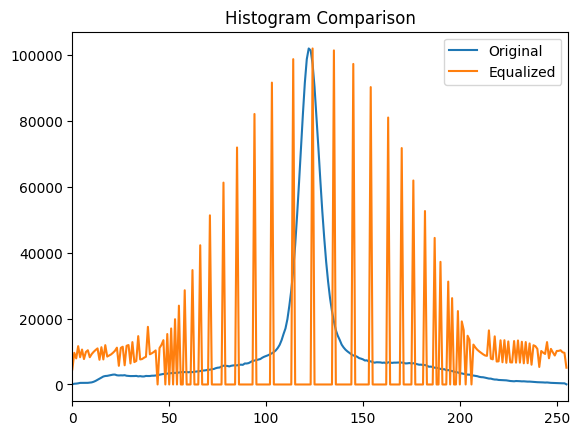

In [1]:
import cv2
import matplotlib.pyplot as plt

image_path = "practice_images/sample.jpg"

image = cv2.imread(image_path)

if image is None:
    print("이미지를 읽을 수 없습니다.")
else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    equalized = cv2.equalizeHist(gray)

    hist_original = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist_equalized = cv2.calcHist([equalized], [0], None, [256], [0, 256])

    cv2.imshow("Original Gray", gray)
    cv2.imshow("Equalized Gray", equalized)

    plt.figure()
    plt.title("Histogram Comparison")
    plt.plot(hist_original, label="Original")
    plt.plot(hist_equalized, label="Equalized")
    plt.xlim([0, 256])
    plt.legend()
    plt.show()

    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [2]:
import cv2

image_path = "practice_images/sample.jpg"

image = cv2.imread(image_path)

if image is None:
    print("이미지를 읽을 수 없습니다.")
else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    equalized = cv2.equalizeHist(gray)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    clahe_image = clahe.apply(gray)

    cv2.imshow("Original Gray", gray)
    cv2.imshow("Histogram Equalization", equalized)
    cv2.imshow("CLAHE", clahe_image)

    cv2.waitKey(0)
    cv2.destroyAllWindows()